# Closed-loop Bayesian test selection for Firebase Chat

This notebook compares One-Hot, TF-IDF with Truncated SVD, Multilingual E5, and Random selection on the same 69 Firebase Chat test cases.

The bug labels are fixed dummy values. They are not application test results or evidence of real defects. The Bayesian optimizer sees a label only after it selects that test case.

## Experiment flow

The notebook reads the QA workbook and checks all 69 cases. Each representation converts the same cases into its own numeric matrix. The experiment runs one initial test per feature, fits a Gaussian Process, scores the untested candidates, selects one case, and then reveals that case's dummy result.

This process continues until every candidate has a position in the final order. The notebook does not test a stopping rule. All methods use the same initial tests, dummy outcomes, costs, and Bayesian settings.

In [1]:
# Install only missing packages. This works in Colab and on a local laptop.
import importlib.util
import os
import subprocess
import sys

RUN_E5 = os.getenv("BAYESIAN_NOTEBOOK_RUN_E5", "1") == "1"
required = {
    "numpy": "numpy",
    "pandas": "pandas",
    "openpyxl": "openpyxl",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
}
missing = [package for module, package in required.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
if RUN_E5 and importlib.util.find_spec("sentence_transformers") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])

print("Environment ready. RUN_E5 =", RUN_E5)

Environment ready. RUN_E5 = True


In [2]:
from pathlib import Path
import json
import math
import re
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import FileLink, display

RANDOM_STATE = 42
BETA = 1.5
COST_EXPONENT = 0.5
E5_MODEL_NAME = "intfloat/multilingual-e5-large-instruct"
AUTO_DOWNLOAD_IN_COLAB = False
DUMMY_BUG_IDS = [
    "FC-LGN-003", "FC-REG-004", "FC-MN-006",
    "FC-NCP-005", "FC-CRP-011", "FC-CRG-004",
    "FC-GPR-003", "FC-MIF-004", "FC-PRF-004",
]

sns.set_theme(style="whitegrid", context="notebook")
np.random.seed(RANDOM_STATE)
print(f"Fixed dummy bugs: {len(DUMMY_BUG_IDS)} IDs")

Fixed dummy bugs: 9 IDs


## 1. Load and validate the QA workbook

On a local laptop, the notebook searches the current folder and its parents for scenarios/firebase_chat/scenario.xlsx. In Colab, it opens a file upload dialog when the workbook is not available.

In [3]:
import re
from pathlib import Path
import numpy as np
import pandas as pd


def parse_minutes(value) -> float:
    """Extract the first numeric duration from the QA Time Testing cell."""
    match = re.search(r"\d+(?:\.\d+)?", str(value))
    if not match:
        raise ValueError(f"Cannot parse Time Testing value: {value!r}")
    return float(match.group())


def choose_initial_seed(cases: pd.DataFrame) -> list[int]:
    """Choose the lexicographically first TCS ID from every Menu."""
    ordered = cases.reset_index().sort_values(["Menu", "TCS ID"], kind="stable")
    return sorted(ordered.groupby("Menu", sort=True).head(1)["index"].tolist())


def find_workbook() -> Path:
    checked = []
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / "scenarios" / "firebase_chat" / "scenario.xlsx"
        checked.append(candidate)
        if candidate.exists():
            return candidate.resolve()

    try:
        from google.colab import files
    except ImportError as exc:
        locations = "\n".join(str(path) for path in checked)
        raise FileNotFoundError(
            "scenario.xlsx was not found. Run from the MAS AI repository or copy the workbook "
            f"to scenarios/firebase_chat/scenario.xlsx. Checked:\n{locations}"
        ) from exc

    print("Upload scenario.xlsx from scenarios/firebase_chat/")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No workbook was uploaded.")
    uploaded_name = next(iter(uploaded))
    return Path(uploaded_name).resolve()


def load_qa_cases(workbook: Path) -> pd.DataFrame:
    raw = pd.read_excel(workbook, header=None)
    matches = np.argwhere(raw.eq("TCS ID").to_numpy())
    if len(matches) == 0:
        raise ValueError("Could not locate the TCS ID header in the workbook.")
    header_row = int(matches[0, 0])
    cases = pd.read_excel(workbook, header=header_row)
    required_columns = [
        "TCS ID", "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario",
        "Test Step", "Expected Result", "Test Type", "User", "Time Testing",
    ]
    missing_columns = [column for column in required_columns if column not in cases.columns]
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    cases = cases.loc[cases["TCS ID"].astype(str).str.startswith("FC-")].copy()
    cases = cases[required_columns].reset_index(drop=True)
    text_columns = [column for column in required_columns if column != "Time Testing"]
    cases[text_columns] = cases[text_columns].fillna("").astype(str)
    cases["estimated_cost"] = cases["Time Testing"].map(parse_minutes)
    if cases["TCS ID"].duplicated().any():
        duplicates = cases.loc[cases["TCS ID"].duplicated(), "TCS ID"].tolist()
        raise ValueError(f"Duplicate TCS IDs: {duplicates}")
    return cases


In [4]:
WORKBOOK_PATH = find_workbook()
cases = load_qa_cases(WORKBOOK_PATH)
if len(cases) != 69:
    raise ValueError(f"This experiment expects 69 Firebase Chat cases, found {len(cases)}.")

unknown_bug_ids = sorted(set(DUMMY_BUG_IDS) - set(cases["TCS ID"]))
if unknown_bug_ids:
    raise ValueError(f"DUMMY_BUG_IDS not found in workbook: {unknown_bug_ids}")

oracle = cases["TCS ID"].isin(DUMMY_BUG_IDS).astype(int).to_numpy()
costs = cases["estimated_cost"].to_numpy(dtype=float)
initial_indices = choose_initial_seed(cases)
ids = cases["TCS ID"].to_numpy()
menus = cases["Menu"].to_numpy()

repo_root = WORKBOOK_PATH.parents[2] if WORKBOOK_PATH.parent.name == "firebase_chat" else Path.cwd()
if (repo_root / "scenarios" / "firebase_chat" / "scenario.xlsx").exists():
    RESULT_DIR = repo_root / "experiment" / "bayesian" / "results"
else:
    RESULT_DIR = Path.cwd() / "experiment" / "bayesian" / "results"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print("Workbook:", WORKBOOK_PATH)
print("Cases:", len(cases), "| Menus/features:", cases["Menu"].nunique())
print("Initial seed:", len(initial_indices), "(one per Menu)")
print("Total estimated cost:", costs.sum(), "minutes")
display(cases[["TCS ID", "Menu", "Test Case Scenario", "estimated_cost"]].head())

Workbook: C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\scenarios\firebase_chat\scenario.xlsx
Cases: 69 | Menus/features: 9
Initial seed: 9 (one per Menu)
Total estimated cost: 632.0 minutes


,TCS ID,Menu,Test Case Scenario,estimated_cost
0,FC-LGN-001,Login,Login berhasil dengan email dan password yang ...,13.0
1,FC-LGN-002,Login,Login gagal - email atau password dikosongkan,12.0
2,FC-LGN-003,Login,Login gagal - kombinasi email dan password salah,11.0
3,FC-LGN-004,Login,Login menggunakan akun Google berhasil,12.0
4,FC-LGN-005,Login,Login menggunakan akun Google dibatalkan oleh ...,15.0


## 2. Fixed dummy outcomes

The experiment uses a fixed list of dummy bugs so every method faces the same problem. The full list is visible to the researcher, but the surrogate model does not receive it.

At each iteration, the surrogate receives only the outcomes of tests that have already run. The fixed Excel order is used later only to place discrete candidates on a readable horizontal axis.

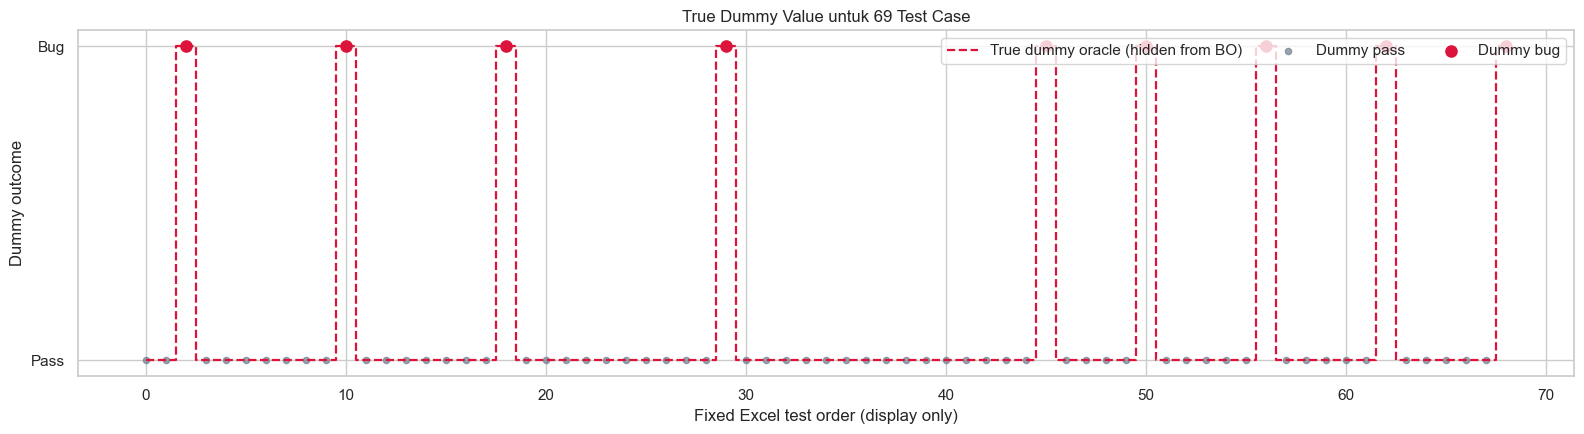

In [5]:
x_display = np.arange(len(cases))
print(f"The fixed oracle contains {int(oracle.sum())} dummy bugs across {len(oracle)} test cases.")

## 3. Independent representation matrices

Each method converts the workbook into its own matrix. The matrices are never combined:

- One-Hot encodes fields such as Menu, Submenu, Test Type, and User.
- TF-IDF uses words and bigrams from the scenario, steps, and expected result. Truncated SVD reduces this matrix to 16 numeric dimensions.
- Multilingual E5 creates semantic embeddings from the same labeled text. It runs locally in the Colab runtime and does not require a paid API.

In [ ]:
TEXT_FIELDS = [
    "Menu", "Submenu 1", "Submenu 2", "Test Case Scenario", "Test Step",
    "Expected Result", "Test Type", "User",
]
CATEGORICAL_FIELDS = ["Menu", "Submenu 1", "Submenu 2", "Test Type", "User"]


def serialize_cases(frame: pd.DataFrame) -> list[str]:
    return [
        "\n".join(f"{field}: {row[field]}" for field in TEXT_FIELDS)
        for _, row in frame.iterrows()
    ]


def normalize_rows(matrix: np.ndarray) -> np.ndarray:
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1, keepdims=True)
    return matrix / np.where(norms == 0, 1.0, norms)


def build_one_hot(frame: pd.DataFrame) -> np.ndarray:
    encoded = pd.get_dummies(frame[CATEGORICAL_FIELDS].astype(str), dtype=float)
    return normalize_rows(encoded.to_numpy())


def tokenize_with_bigrams(text: str) -> list[str]:
    tokens = re.findall(r"(?u)\b\w\w+\b", text.lower())
    return tokens + [f"{left}__{right}" for left, right in zip(tokens, tokens[1:])]


def build_tfidf_svd(frame: pd.DataFrame, random_state: int = 42) -> tuple[np.ndarray, list[str], np.ndarray]:
    documents = [tokenize_with_bigrams(text) for text in serialize_cases(frame)]
    vocabulary = sorted({token for document in documents for token in document})
    token_to_column = {token: column for column, token in enumerate(vocabulary)}
    counts = np.zeros((len(documents), len(vocabulary)), dtype=float)
    document_frequency = np.zeros(len(vocabulary), dtype=float)
    for row, document in enumerate(documents):
        for token in document:
            counts[row, token_to_column[token]] += 1.0
        for token in set(document):
            document_frequency[token_to_column[token]] += 1.0
    sublinear_tf = np.where(counts > 0, 1.0 + np.log(np.maximum(counts, 1.0)), 0.0)
    inverse_document_frequency = np.log((1.0 + len(documents)) / (1.0 + document_frequency)) + 1.0
    tfidf = normalize_rows(sublinear_tf * inverse_document_frequency)
    components = min(16, tfidf.shape[0] - 1, tfidf.shape[1] - 1)
    left_vectors, singular_values, right_vectors = np.linalg.svd(tfidf, full_matrices=False)
    dense = left_vectors[:, :components] * singular_values[:components]
    return normalize_rows(dense), vocabulary, right_vectors[:components]


def build_e5(frame: pd.DataFrame, model_name: str, result_dir: Path) -> np.ndarray:
    from sentence_transformers import SentenceTransformer

    instruction = (
        "Represent this Android QA test case so cases exercising similar features, "
        "actions, and expected behaviors are close."
    )
    inputs = [f"Instruct: {instruction}\nQuery: {text}" for text in serialize_cases(frame)]
    model = SentenceTransformer(model_name)
    embeddings = model.encode(
        inputs,
        normalize_embeddings=True,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    np.save(result_dir / "e5_embeddings.npy", embeddings)
    return embeddings


one_hot_matrix = build_one_hot(cases)
tfidf_svd_matrix, tfidf_vocabulary, tfidf_components = build_tfidf_svd(cases, RANDOM_STATE)
representations = {
    "One-Hot": one_hot_matrix,
    "TF-IDF + SVD": tfidf_svd_matrix,
}
if RUN_E5:
    representations["Multilingual E5"] = build_e5(cases, E5_MODEL_NAME, RESULT_DIR)
else:
    print("Multilingual E5 skipped only because BAYESIAN_NOTEBOOK_RUN_E5=0.")

for name, matrix in representations.items():
    assert matrix.shape[0] == len(cases), f"{name} row mismatch"
    assert np.isfinite(matrix).all(), f"{name} contains non-finite values"
    print(f"{name:20s} -> {matrix.shape}")

C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\radit\Project\VisualStudioProject\Skripsi\MAS AI\venv\Lib\site-packages\huggingface_hub\file_download.py:135: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\radit\.cache\huggingface\hub\models--intfloat--multilingual-e5-large-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Develo

## 4. Closed-loop Bayesian selection

The first experiment uses Gaussian Process Regression as a transparent surrogate. The dummy outcome is binary, so this model is an initial approximation rather than a validated final classifier.

The run starts with one test from every Menu. It then selects the next untested candidate with cost-aware UCB:

utility = clipped_mean + beta × uncertainty

acquisition = utility / cost^cost_exponent

The predicted mean favors candidates that may expose a bug. Uncertainty lets the optimizer explore less familiar cases. Dividing by cost gives a mild preference to shorter tests.

In [ ]:
import numpy as np
import pandas as pd


def _squared_distances(left: np.ndarray, right: np.ndarray) -> np.ndarray:
    return np.maximum(
        np.sum(left * left, axis=1)[:, None]
        + np.sum(right * right, axis=1)[None, :]
        - 2.0 * left @ right.T,
        0.0,
    )


def _gp_predict(train_x, train_y, candidate_x, length_scale=1.0, noise=1e-3):
    """Fixed-kernel Gaussian Process posterior implemented with NumPy."""
    train_x = np.asarray(train_x, dtype=float)
    candidate_x = np.asarray(candidate_x, dtype=float)
    train_y = np.asarray(train_y, dtype=float)
    train_kernel = np.exp(-0.5 * _squared_distances(train_x, train_x) / length_scale**2)
    train_kernel += (noise + 1e-8) * np.eye(len(train_x))
    cross_kernel = np.exp(-0.5 * _squared_distances(train_x, candidate_x) / length_scale**2)
    cholesky = np.linalg.cholesky(train_kernel)
    weights = np.linalg.solve(cholesky.T, np.linalg.solve(cholesky, train_y))
    mean = cross_kernel.T @ weights
    projected = np.linalg.solve(cholesky, cross_kernel)
    variance = np.maximum(1.0 - np.sum(projected * projected, axis=0), 1e-12)
    return mean, np.sqrt(variance)


def _finalize_order(rows: list[dict]) -> pd.DataFrame:
    result = pd.DataFrame(rows)
    result["execution_position"] = np.arange(1, len(result) + 1)
    result["cumulative_bugs"] = result["confirmed_bug_dummy"].cumsum()
    result["cumulative_cost"] = result["estimated_cost"].cumsum()
    return result[
        [
            "execution_position", "tcs_id", "menu", "estimated_cost",
            "is_initial_seed", "predicted_mean", "predicted_std", "acquisition",
            "confirmed_bug_dummy", "cumulative_bugs", "cumulative_cost",
        ]
    ]


def run_closed_loop(
    matrix,
    ids,
    menus,
    costs,
    oracle,
    initial_indices,
    beta=1.5,
    cost_exponent=0.5,
    snapshot_counts=None,
    random_state=42,
):
    """Return a full order while revealing only selected oracle labels."""
    matrix = np.asarray(matrix, dtype=float)
    ids = np.asarray(ids, dtype=str)
    menus = np.asarray(menus, dtype=str)
    costs = np.asarray(costs, dtype=float)
    oracle = np.asarray(oracle, dtype=int)
    if not (len(matrix) == len(ids) == len(menus) == len(costs) == len(oracle)):
        raise ValueError("matrix, ids, menus, costs, and oracle must have equal lengths")
    if np.any(costs <= 0):
        raise ValueError("All estimated costs must be positive")

    revealed = list(dict.fromkeys(int(index) for index in initial_indices))
    if not revealed:
        raise ValueError("At least one initial test is required")
    snapshot_counts = set(snapshot_counts or [])
    audit = []
    snapshots = []
    rows = [
        {
            "tcs_id": ids[index],
            "menu": menus[index],
            "estimated_cost": costs[index],
            "is_initial_seed": True,
            "predicted_mean": np.nan,
            "predicted_std": np.nan,
            "acquisition": np.nan,
            "confirmed_bug_dummy": int(oracle[index]),
        }
        for index in revealed
    ]

    while len(revealed) < len(ids):
        training_indices = list(revealed)
        mean, std = _gp_predict(matrix[training_indices], oracle[training_indices], matrix)

        remaining = np.array([index for index in range(len(ids)) if index not in set(revealed)], dtype=int)
        utility = np.clip(mean, 0.0, 1.0) + beta * std
        acquisition = np.full(len(ids), np.nan, dtype=float)
        acquisition[remaining] = utility[remaining] / np.power(
            np.maximum(costs[remaining], 1.0), cost_exponent
        )
        best_value = np.nanmax(acquisition[remaining])
        tied = remaining[np.isclose(acquisition[remaining], best_value)]
        selected = int(min(tied, key=lambda index: ids[index]))

        audit.append(
            {
                "train_count": len(training_indices),
                "revealed_count": len(revealed),
                "training_indices": list(training_indices),
                "revealed_indices": list(revealed),
                "selected_index": selected,
            }
        )
        if len(revealed) in snapshot_counts:
            snapshots.append(
                {
                    "tested_count": len(revealed),
                    "observed_indices": list(revealed),
                    "selected_index": selected,
                    "mean": mean.copy(),
                    "std": std.copy(),
                    "acquisition": acquisition.copy(),
                }
            )

        rows.append(
            {
                "tcs_id": ids[selected],
                "menu": menus[selected],
                "estimated_cost": costs[selected],
                "is_initial_seed": False,
                "predicted_mean": float(mean[selected]),
                "predicted_std": float(std[selected]),
                "acquisition": float(acquisition[selected]),
                "confirmed_bug_dummy": int(oracle[selected]),
            }
        )
        revealed.append(selected)

    return _finalize_order(rows), audit, snapshots


def run_random_baseline(ids, menus, costs, oracle, initial_indices, random_state=42):
    rng = np.random.default_rng(random_state)
    initial = list(dict.fromkeys(int(index) for index in initial_indices))
    remaining = np.array([index for index in range(len(ids)) if index not in set(initial)], dtype=int)
    rng.shuffle(remaining)
    ordering = initial + remaining.tolist()
    rows = [
        {
            "tcs_id": ids[index],
            "menu": menus[index],
            "estimated_cost": costs[index],
            "is_initial_seed": index in set(initial),
            "predicted_mean": np.nan,
            "predicted_std": np.nan,
            "acquisition": np.nan,
            "confirmed_bug_dummy": int(oracle[index]),
        }
        for index in ordering
    ]
    return _finalize_order(rows)


In [ ]:
snapshot_counts = {
    len(initial_indices),
    min(len(cases) - 1, len(initial_indices) + 5),
    min(len(cases) - 1, len(initial_indices) + 15),
    min(len(cases) - 1, len(initial_indices) + 30),
}

runs = {}
audits = {}
snapshots_by_method = {}
for method_name, matrix in representations.items():
    run, audit, snapshots = run_closed_loop(
        matrix=matrix,
        ids=ids,
        menus=menus,
        costs=costs,
        oracle=oracle,
        initial_indices=initial_indices,
        beta=BETA,
        cost_exponent=COST_EXPONENT,
        snapshot_counts=snapshot_counts,
        random_state=RANDOM_STATE,
    )
    runs[method_name] = run
    audits[method_name] = audit
    snapshots_by_method[method_name] = snapshots

runs["Random"] = run_random_baseline(ids, menus, costs, oracle, initial_indices, RANDOM_STATE)

for method_name, run in runs.items():
    assert set(run["tcs_id"]) == set(cases["TCS ID"])
    assert run["tcs_id"].is_unique
    assert run["cumulative_bugs"].is_monotonic_increasing
    assert run["cumulative_cost"].is_monotonic_increasing
    assert int(run["cumulative_bugs"].iloc[-1]) == int(oracle.sum())
    print(f"{method_name:20s}: first dummy bug at test #{int(run.loc[run['confirmed_bug_dummy'].eq(1), 'execution_position'].min())}")

## 5. Convergence plot

This chart shows how many dummy bugs each method has found after each executed test. A curve that rises earlier has found more of the fixed dummy bugs with fewer test executions. Random selection provides a baseline.

In [ ]:
colors = {
    "One-Hot": "#1f77b4",
    "TF-IDF + SVD": "#ff7f0e",
    "Multilingual E5": "#2ca02c",
    "Random": "#7f7f7f",
}

fig, ax = plt.subplots(figsize=(11, 6))
for method_name, run in runs.items():
    ax.step(run["execution_position"], run["cumulative_bugs"], where="post",
            linewidth=2.2, color=colors.get(method_name), label=method_name)
ax.axhline(oracle.sum(), color="crimson", linestyle="--", alpha=0.7, label="All dummy bugs")
ax.set(title="Convergence: Cumulative Dummy Bugs vs Executed Tests",
       xlabel="Number of executed test cases", ylabel="Cumulative dummy bugs found")
ax.legend()
fig.tight_layout()
fig.savefig(RESULT_DIR / "convergence.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Snapshot setup

The next figure uses the fixed Excel order to place the 69 discrete candidates on one readable axis. Connecting lines are visual guides. They do not turn the test cases into a continuous objective function.

In [ ]:
print("Snapshot counts:", sorted(snapshot_counts))

## 7. Posterior and acquisition snapshots

Each Bayesian representation gets its own figure. The left column shows the fixed dummy truth, the Gaussian Process mean, its uncertainty band, and the outcomes revealed so far. The right column shows the acquisition score used to choose the next test.

Random selection does not have a surrogate model, so it appears in the convergence chart but not in these snapshots.

In [ ]:
for method_name, method_snapshots in snapshots_by_method.items():
    fig, axes = plt.subplots(
        len(method_snapshots),
        2,
        figsize=(15, 3.8 * len(method_snapshots)),
        squeeze=False,
    )

    for row, snapshot in enumerate(method_snapshots):
        mean = snapshot["mean"]
        std = snapshot["std"]
        observed = np.array(snapshot["observed_indices"], dtype=int)
        selected = snapshot["selected_index"]
        display_acquisition = np.nan_to_num(snapshot["acquisition"], nan=0.0)

        left = axes[row, 0]
        left.step(
            x_display,
            oracle,
            where="mid",
            color="red",
            linestyle="--",
            linewidth=1.5,
            label="True dummy value (unknown to BO)",
        )
        left.plot(x_display, mean, color="green", linestyle="--", linewidth=1.7, label="GP mean")
        left.fill_between(
            x_display,
            mean - 1.96 * std,
            mean + 1.96 * std,
            color="green",
            alpha=0.18,
            label="95% uncertainty band",
        )
        left.scatter(observed, oracle[observed], color="red", s=34, zorder=4, label="Observations")
        left.set_ylim(-0.35, 1.35)
        left.set_title(f"Posterior after {snapshot['tested_count']} observed tests")
        left.set_xlabel("Test case index in fixed Excel order")
        left.set_ylabel("Dummy outcome and GP score")
        if row == 0:
            left.legend(loc="upper right", fontsize=8)

        right = axes[row, 1]
        right.plot(x_display, display_acquisition, color="blue", linewidth=1.8, label="Acquisition E(x)")
        right.fill_between(x_display, 0, display_acquisition, color="blue", alpha=0.3)
        right.scatter(
            [selected],
            [display_acquisition[selected]],
            color="blue",
            s=70,
            zorder=4,
            label=f"Next query: {ids[selected]}",
        )
        right.set_title("Acquisition and next test case")
        right.set_xlabel("Test case index in fixed Excel order")
        right.set_ylabel("Cost-aware UCB acquisition")
        right.set_ylim(bottom=0)
        right.legend(loc="upper right", fontsize=8)

    fig.suptitle(f"{method_name}: Gaussian Process and acquisition", y=1.002, fontsize=15)
    fig.tight_layout()
    safe_name = re.sub(r"[^a-z0-9]+", "_", method_name.lower()).strip("_")
    fig.savefig(RESULT_DIR / f"iteration_snapshots_{safe_name}.png", dpi=180, bbox_inches="tight")
    plt.show()

## 8. Summary and export

Normalized AUC summarizes the cumulative-bugs curve. A higher value means that a method found the fixed dummy bugs earlier. This comparison is valid only because every method uses the same dummy outcomes.

In [ ]:
summary_rows = []
for method_name, run in runs.items():
    bug_rows = run.loc[run["confirmed_bug_dummy"].eq(1)]
    area = np.trapezoid(run["cumulative_bugs"], run["execution_position"])
    max_area = max(1.0, float(oracle.sum() * (len(run) - 1)))
    summary_rows.append(
        {
            "method": method_name,
            "first_dummy_bug_position": int(bug_rows["execution_position"].min()),
            "bugs_by_20_tests": int(run.loc[run["execution_position"].le(20), "cumulative_bugs"].max()),
            "normalized_auc_by_tests": float(area / max_area),
            "cost_when_all_dummy_bugs_found": float(bug_rows["cumulative_cost"].max()),
        }
    )

summary = pd.DataFrame(summary_rows).sort_values("normalized_auc_by_tests", ascending=False).reset_index(drop=True)
display(summary.style.format({"normalized_auc_by_tests": "{:.3f}", "cost_when_all_dummy_bugs_found": "{:.1f}"}))

for method_name, run in runs.items():
    safe_name = re.sub(r"[^a-z0-9]+", "_", method_name.lower()).strip("_")
    run.to_csv(RESULT_DIR / f"ordering_{safe_name}.csv", index=False)
summary.to_csv(RESULT_DIR / "summary.csv", index=False)

config = {
    "random_state": RANDOM_STATE,
    "beta": BETA,
    "cost_exponent": COST_EXPONENT,
    "run_e5": RUN_E5,
    "e5_model_name": E5_MODEL_NAME,
    "dummy_bug_ids": DUMMY_BUG_IDS,
    "initial_tcs_ids": cases.iloc[initial_indices]["TCS ID"].tolist(),
}
with (RESULT_DIR / "experiment_config.json").open("w", encoding="utf-8") as handle:
    json.dump(config, handle, indent=2, ensure_ascii=False)

archive_base = RESULT_DIR.parent / "bayesian_dummy_results"
archive_path = Path(shutil.make_archive(str(archive_base), "zip", root_dir=RESULT_DIR))
print("Results:", RESULT_DIR)
print("ZIP:", archive_path)
display(FileLink(str(archive_path)))

if AUTO_DOWNLOAD_IN_COLAB:
    try:
        from google.colab import files
        files.download(str(archive_path))
    except ImportError:
        pass

## How to read the result

A method performs better in this closed experiment when its convergence curve rises earlier. That result only shows how well the method matches the fixed dummy pattern. It does not prove that the same method will find real application bugs earlier. A later experiment can replace the dummy oracle with real execution outcomes while keeping the selection loop and comparison metrics unchanged.